In [13]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from devito import configuration
from matplotlib import pyplot as plt


PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = "../data/21-20.sgy"
NBL=500
SO=4
TMAX = 40.0

configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"

def setup_model_and_geometry(iter_num):
    """Set up the velocity model and acquisition geometry"""
    dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
    xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
    spacing = (0.025, 0.025)
    velmodel = VelocityModel(
        PATH_MODEL,
        dx=spacing[0],
        dz=spacing[1],
        clip=True,
        xmin=xmin - 3,
        xmax=xmax + 3,
        zmin=-318,
    )
    velmodel.pad_left(4 + 2)
    velmodel.pad_right(8 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_bottom(10 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_top(7 * int(0.5 / spacing[0]))

    vp = velmodel.vp.T
    origin = velmodel.x[0], velmodel.z[0]
    model = SeismicModel(
        vp=vp,
        origin=origin,
        shape=vp.shape,
        spacing=spacing,
        space_order=SO,
        nbl=NBL,
        bcs="damp",
        fs=False,
    )
    return model, dataset

In [14]:
model, dataset = setup_model_and_geometry(0)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

Operator `initdamp` ran in 0.01 s


In [15]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]

t0 = 0
tn = TMAX

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

Operator `Forward` ran in 5.15 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitialized (zero) source
Operator `Adjoint` ran in 5.05 s


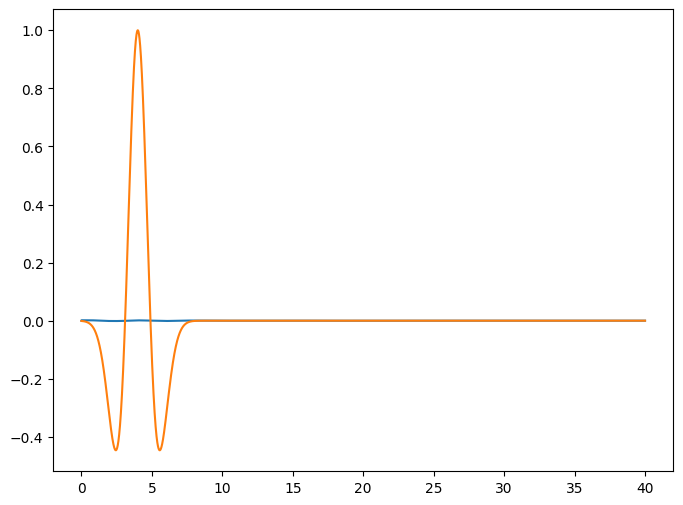

In [16]:
plt.plot(geometry.time_axis.time_values, srca.data[:])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [17]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [18]:
gradient_tapered.shape
alpha
current_wavelet.shape

(12972,)

No source type defined, returning uninitiallized (zero) source


No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 4.95 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 4.92 s
No source type defined, returning uninitiallized (zero) source


14.96845051783868
Iter 0: Misfit = 1.4972e+05


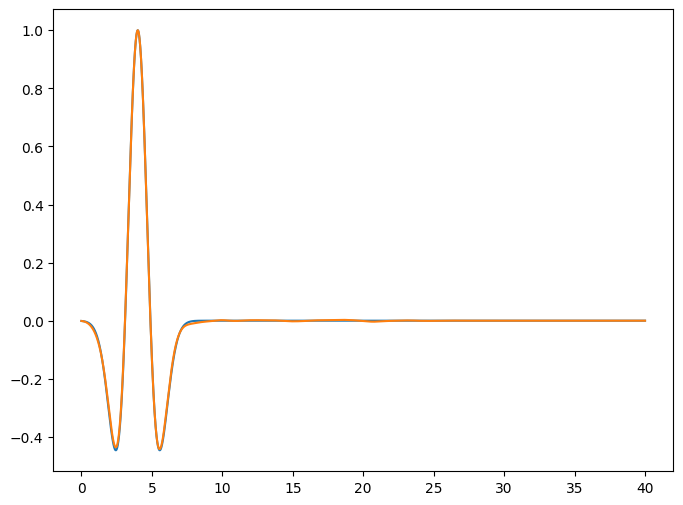

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 5.07 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 5.08 s
No source type defined, returning uninitiallized (zero) source


14.41948172644748
Iter 1: Misfit = 1.3708e+05


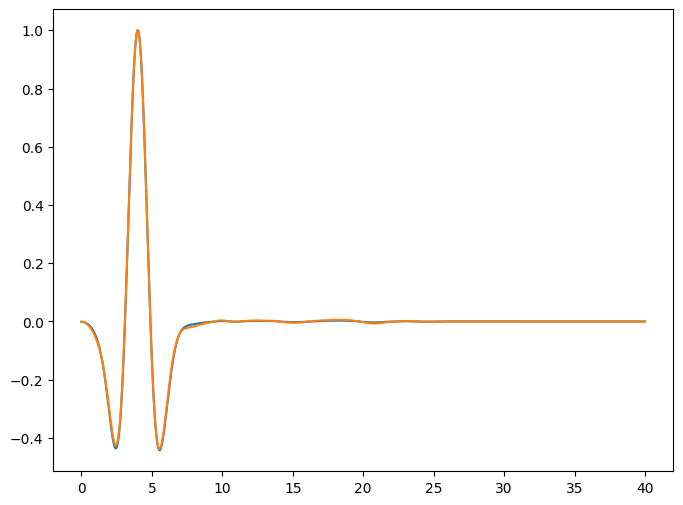

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 5.09 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 5.10 s
No source type defined, returning uninitiallized (zero) source


13.89067698132625
Iter 2: Misfit = 1.2582e+05


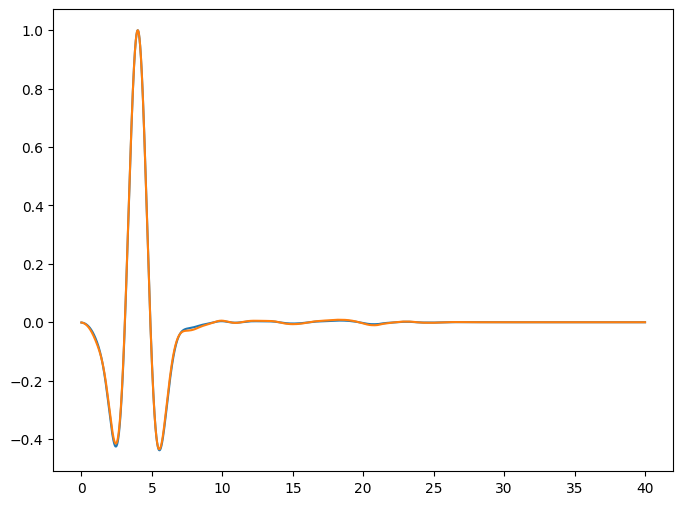

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 5.10 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 5.12 s
No source type defined, returning uninitiallized (zero) source


13.381426260568237
Iter 3: Misfit = 1.1578e+05


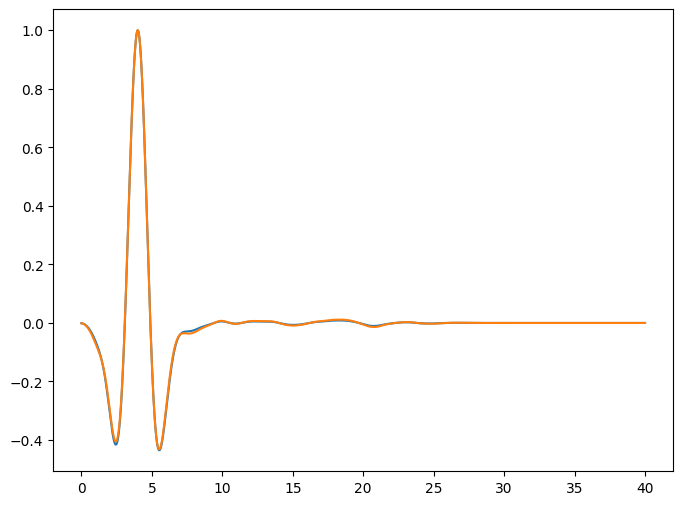

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 5.13 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 5.01 s
No source type defined, returning uninitiallized (zero) source


12.890702980481558
Iter 4: Misfit = 1.0682e+05


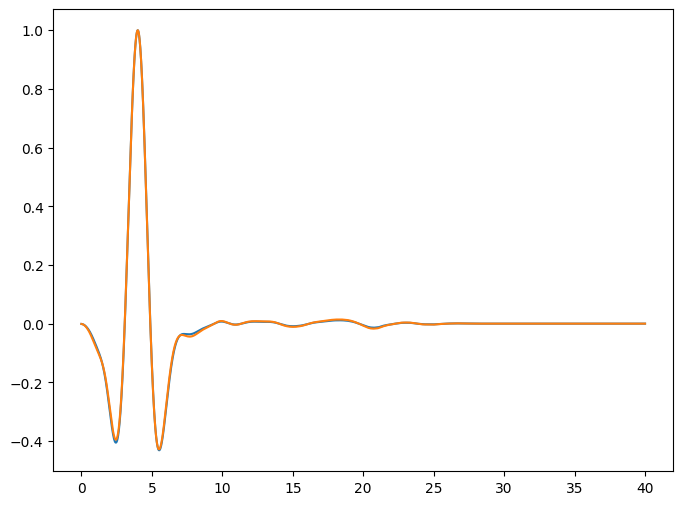

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 4.97 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 4.86 s
No source type defined, returning uninitiallized (zero) source


12.41794009641505
Iter 5: Misfit = 9.8800e+04


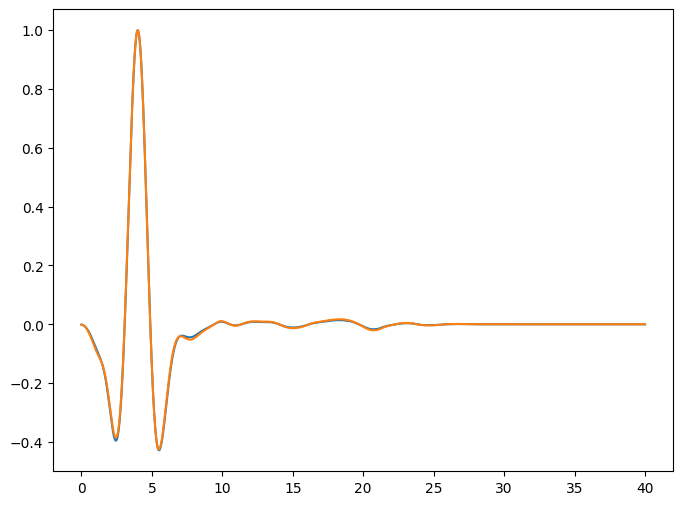

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Forward` ran in 5.00 s
No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source
Operator `Adjoint` ran in 5.00 s
No source type defined, returning uninitiallized (zero) source


11.962551328917634
Iter 6: Misfit = 9.1621e+04


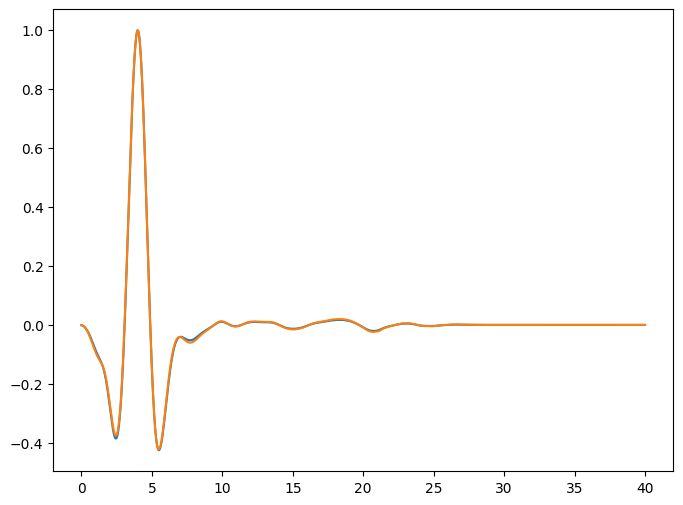

No source type defined, returning uninitiallized (zero) source
No source type defined, returning uninitiallized (zero) source


In [ ]:
max_iter = 10
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
current_wavelet = geometry.src.data[:].reshape(-1)
inittial_wavelet = np.copy(current_wavelet)
for i in range(max_iter):
    # Forward modeling
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, rec=d_syn, save=False)
    residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
    residual.data[:] = d_syn.data[:] - d_obs.T
    
    # Compute gradient (adjoint source)
    srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
    gradient = srca.data
    gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
    misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
    alpha = 0.05 * calculate_step_size(misfit, gradient)
    print(alpha)
    # Update wavelet
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    current_wavelet = current_wavelet - alpha * gradient_tapered
    print(f"Iter {i}: Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))

    plt.show()

In [29]:
d_syn.data[:].min()

Data(-3.1088086e-05, dtype=float32)

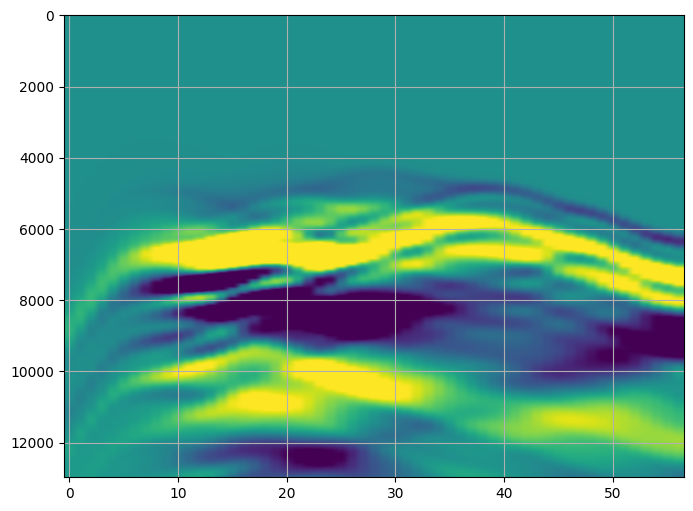

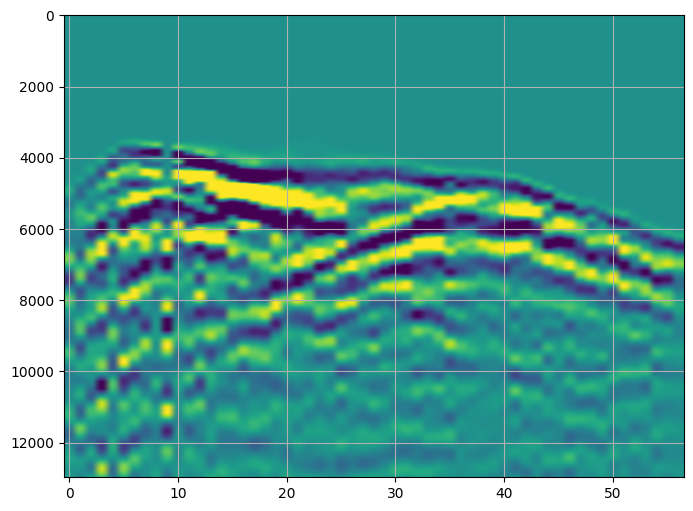

In [34]:
from matplotlib import pyplot as plt
qa = np.quantile(np.array(d_syn.data[:]).ravel(), 0.95)
plt.imshow(d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()
qa = np.quantile(d_obs, 0.98)
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()

plt.show()